# Notebook 3 — Logbasierte Case-Level-Komponente

**Ziel:** Case-Level Log-Klassifikation für CloudAnoBench.  
Unterscheidung von `mali` gegenüber (`anom` + `norm`) auf Basis normalisierter Syslog-Texte.

**Log-Normalisierung:**
- Synthetische Artefakte (Timestamps, IPs, PIDs, Ports, reine Zahlen) werden vor TF-IDF durch
  Token-Platzhalter ersetzt (`TOKEN_IP`, `TOKEN_TIME`, `TOKEN_PID`, `TOKEN_PORT`, `TOKEN_NUM`)
- Damit lernt TF-IDF semantische Muster statt synthetischer Varianz

**Methodische Kernelemente:**
- Split aus `docs/split_assignments.csv` (kein eigenständiger GroupShuffleSplit)
- TF-IDF `fit_transform` **ausschließlich auf Train** — `transform` auf Val/Test
- Logistic Regression **ausschließlich auf Train** trainiert
- Threshold auf **Validation** bei `Recall_mali ≥ 0.95`
- **Testset** nur für finale Evaluation

**Input:** `data/processed/*.parquet` + `data/*_dataset/*/*.log` + `docs/split_assignments.csv`  
**Output:** `docs/log_val_scores.csv`, `docs/log_test_scores.csv`, `docs/log_results.csv`,
`docs/threshold_sensitivity_log.csv`, `docs/log_preprocessing_examples.csv`,
`docs/pr_curve_log.png`, `docs/tfidf_top_features.png`

In [1]:
import pandas as pd
import os
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score, confusion_matrix, precision_recall_curve,
    average_precision_score, f1_score, precision_score
)
import time
import matplotlib.pyplot as plt

base_path      = os.path.join(os.getcwd(), "..", "data")
processed_path = os.path.join(base_path, "processed")
docs_path      = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# ─── Case-Metadaten und Log-Texte laden ──────────────────────────────────────
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)

case_meta = (
    all_data
    .drop_duplicates(subset='case_id')
    [['case_id', 'scenario_id', 'dataset_type', 'label']]
    .reset_index(drop=True)
)
case_meta['group_id'] = case_meta['dataset_type'] + '_' + case_meta['scenario_id'].astype(str)

def load_log_text(row):
    """Laedt Syslog-Text einer Case-Datei. Leerer String wenn Datei fehlt."""
    log_filename = row['case_id'].replace('.csv', '.log')
    log_path = os.path.join(
        base_path, f"{row['dataset_type']}_dataset",
        row['scenario_id'], log_filename
    )
    if os.path.exists(log_path):
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return ""

case_meta['raw_log_text'] = case_meta.apply(load_log_text, axis=1)

missing = (case_meta['raw_log_text'] == "").sum()
print(f"Cases gesamt:          {len(case_meta)}")
print(f"Cases mit Log-Text:    {(case_meta['raw_log_text'] != '').sum()}")
print(f"Cases ohne Log-Datei:  {missing}")
print(f"\nLabel-Verteilung (Case-Ebene):\n{case_meta['label'].value_counts().sort_index()}")

Cases gesamt:          1252
Cases mit Log-Text:    1252
Cases ohne Log-Datei:  0

Label-Verteilung (Case-Ebene):
label
0    1029
1     223
Name: count, dtype: int64


In [3]:
# ─── Split aus split_assignments.csv laden ────────────────────────────────────
# Kein eigenstaendiger GroupShuffleSplit — identische Gruppen-Zuweisung wie NB02.
split_df = pd.read_csv(os.path.join(docs_path, "split_assignments.csv"))

case_log_df = case_meta.merge(
    split_df[['case_id', 'split']], on='case_id', how='left'
)

# Integritaetspruefungen
assert case_log_df['case_id'].nunique() == len(case_log_df), "Duplizierte case_ids!"
assert not case_log_df['split'].isnull().any(), "Fehlende Split-Zuweisung!"
assert set(case_log_df['split'].unique()) <= {'train', 'val', 'test'}, "Unbekannte Split-Werte!"

g_tr = set(case_log_df[case_log_df['split'] == 'train']['group_id'])
g_vl = set(case_log_df[case_log_df['split'] == 'val']['group_id'])
g_te = set(case_log_df[case_log_df['split'] == 'test']['group_id'])
assert len(g_tr & g_vl) == 0, "Train/Val Gruppen-Ueberlappung!"
assert len(g_vl & g_te) == 0, "Val/Test Gruppen-Ueberlappung!"
assert len(g_tr & g_te) == 0, "Train/Test Gruppen-Ueberlappung!"
print("\u2713 Gruppen-Disjunktheit bestaetigt")

train_df = case_log_df[case_log_df['split'] == 'train'].reset_index(drop=True)
val_df   = case_log_df[case_log_df['split'] == 'val'].reset_index(drop=True)
test_df  = case_log_df[case_log_df['split'] == 'test'].reset_index(drop=True)

neg = int((train_df['label'] == 0).sum())
pos = int((train_df['label'] == 1).sum())

print(f"Train: {len(train_df)} Cases | Val: {len(val_df)} Cases | Test: {len(test_df)} Cases")
print(f"Train mali={pos}, negativ={neg}  => Ratio: {neg/pos:.2f}")
print(f"Val   mali={int((val_df['label']==1).sum())}, negativ={int((val_df['label']==0).sum())}")
print(f"Test  mali={int((test_df['label']==1).sum())}, negativ={int((test_df['label']==0).sum())}")
print(f"\nTest dataset_type breakdown:\n{test_df['dataset_type'].value_counts().to_string()}")

✓ Gruppen-Disjunktheit bestaetigt


Train: 793 Cases | Val: 206 Cases | Test: 253 Cases
Train mali=122, negativ=671  => Ratio: 5.50
Val   mali=53, negativ=153
Test  mali=48, negativ=205

Test dataset_type breakdown:
dataset_type
norm    129
anom     76
mali     48


In [4]:
# ─── Log-Normalisierung ───────────────────────────────────────────────────────
#
# Ziel: TF-IDF soll semantische Muster lernen (Fehlermeldungen, anomale Prozessnamen,
# Attack-Keywords), NICHT synthetische Varianz (Zeitstempel, PIDs, IPs, Ports).
#
# Tokens: TOKEN_IP, TOKEN_TIME, TOKEN_DATE, TOKEN_PID, TOKEN_PORT, TOKEN_NUM, TOKEN_ID
# Vorteil gegenueber <TAG>: Unterstrich in TOKEN_* ist ein Wortzeichen (\w),
#   daher zuverlaessig von TF-IDF default token_pattern erfasst.
#
# Bewusst ERHALTEN (Attack-relevante Semantik):
#   - Prozessnamen: sshd, CRON, wget, curl, bash, sudo, nginx, systemd, ...
#   - Aktionen: Accepted, Failed, CMD, exec, download, script, ...
#   - Pfade und Domains: /etc/cron.hourly, malicious-domain.com/setup.sh, ...
#   - Protokollbezeichner: ssh2, HTTP, GET, POST, ...
#
# Reihenfolge ist entscheidend: spezifische Patterns vor allgemeinen.

def normalize_log_text(text: str) -> str:
    """
    Normalisiert synthetische Log-Artefakte vor TF-IDF.
    Deterministisch und regelbasiert — kein Daten-Leakage moeglich.
    """
    # 1. UUIDs: "550e8400-e29b-41d4-a716-446655440000"
    text = re.sub(
        r'\b[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}\b',
        'TOKEN_ID', text
    )
    # 2. Nginx-Timestamp: "[20/Aug/2025:08:01:10 +0000]"
    text = re.sub(
        r'\[\d{1,2}/(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'
        r'/\d{4}:\d{2}:\d{2}:\d{2}\s[+-]\d{4}\]',
        'TOKEN_TIME', text
    )
    # 3. Syslog-Timestamp: "Aug 15 10:00:05" oder "Jul  2 11:00:00"
    text = re.sub(
        r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'
        r'\s{1,2}\d{1,2}\s+\d{2}:\d{2}:\d{2}\b',
        'TOKEN_TIME', text
    )
    # 4. ISO-Timestamp mit Zeit: "2024-01-12T13:45:22Z" oder "2024/01/12 13:45:22"
    text = re.sub(
        r'\d{4}[-/]\d{2}[-/]\d{2}[T ]\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})?',
        'TOKEN_TIME', text
    )
    # 5. ISO-Datum: "2024-01-12" oder "2024/01/12"
    text = re.sub(r'\d{4}[-/]\d{2}[-/]\d{2}', 'TOKEN_DATE', text)
    # 6. Uhrzeit: "13:45:22" oder "13:45"
    text = re.sub(r'\b\d{2}:\d{2}(?::\d{2})?\b', 'TOKEN_TIME', text)
    # 7. IPv4-Adresse: "192.168.1.10" oder "10.0.2.5"
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', 'TOKEN_IP', text)
    # 8. PIDs in eckigen Klammern: "sshd[11532]" -> "sshd[TOKEN_PID]"
    text = re.sub(r'\[(\d+)\]', '[TOKEN_PID]', text)
    # 9. Port-Keywords: "port 54321", "port=5432"
    text = re.sub(r'\bport[= ]+\d+\b', 'port TOKEN_PORT', text, flags=re.IGNORECASE)
    # 10. Kolonstil-Port nach Buchstaben: "domain.com:8080", "localhost:443"
    text = re.sub(r'(?<=[a-zA-Z]):\d{2,5}\b', ':TOKEN_PORT', text)
    # 11. Isolierte Zahlen (nach allen spezifischen Patterns)
    #     \b\d+\b trifft nur isolierte Integer, nicht Teile von Bezeichnern wie ssh2 oder v1
    text = re.sub(r'\b\d+\b', 'TOKEN_NUM', text)
    return text

# Normalisierung auf ALLE Cases (regelbasiert, kein Leakage)
case_log_df['normalized_log_text'] = case_log_df['raw_log_text'].apply(normalize_log_text)

# Splits nach Normalisierung neu zuweisen
train_df = case_log_df[case_log_df['split'] == 'train'].reset_index(drop=True)
val_df   = case_log_df[case_log_df['split'] == 'val'].reset_index(drop=True)
test_df  = case_log_df[case_log_df['split'] == 'test'].reset_index(drop=True)

# ─── Preprocessing-Beispiele speichern (15 Cases: 5 mali, 5 anom, 5 norm) ────
sample_parts = []
for dt in ['mali', 'anom', 'norm']:
    subset = case_log_df[case_log_df['dataset_type'] == dt]
    sample_parts.append(subset.sample(min(5, len(subset)), random_state=42))
examples_df = pd.concat(sample_parts, ignore_index=True).copy()
examples_df['raw_excerpt']        = examples_df['raw_log_text'].str[:250]
examples_df['normalized_excerpt'] = examples_df['normalized_log_text'].str[:250]
examples_df[['case_id', 'split', 'label', 'dataset_type', 'raw_excerpt', 'normalized_excerpt']].to_csv(
    os.path.join(docs_path, "log_preprocessing_examples.csv"), index=False
)
print("\u2713 Log-Normalisierung abgeschlossen")
print(f"\u2713 log_preprocessing_examples.csv gespeichert (15 Stichproben)")

# Exemplarische Ausgabe
mali_ex = case_log_df[case_log_df['dataset_type'] == 'mali'].iloc[0]
print("\n--- Beispiel mali (erste 200 Zeichen) ---")
print("RAW: ", repr(mali_ex['raw_log_text'][:200]))
print("NORM:", repr(mali_ex['normalized_log_text'][:200]))

norm_ex = case_log_df[case_log_df['dataset_type'] == 'anom'].iloc[0]
print("\n--- Beispiel anom (erste 200 Zeichen) ---")
print("RAW: ", repr(norm_ex['raw_log_text'][:200]))
print("NORM:", repr(norm_ex['normalized_log_text'][:200]))

✓ Log-Normalisierung abgeschlossen
✓ log_preprocessing_examples.csv gespeichert (15 Stichproben)

--- Beispiel mali (erste 200 Zeichen) ---
RAW:  'Aug 15 10:00:05 systemd[1]: Started Session 5 of user admin.\nAug 15 10:00:15 sshd[11532]: Accepted publickey for admin from 10.0.2.5 port 54321 ssh2\nAug 15 10:00:40 cron[11590]: (root) CMD (   /usr/li'
NORM: 'TOKEN_TIME systemd[TOKEN_PID]: Started Session TOKEN_NUM of user admin.\nTOKEN_TIME sshd[TOKEN_PID]: Accepted publickey for admin from TOKEN_IP port TOKEN_PORT ssh2\nTOKEN_TIME cron[TOKEN_PID]: (root) C'

--- Beispiel anom (erste 200 Zeichen) ---
RAW:  'Jul 02 11:00:00 systemd[1]: Starting daily clean up activities...\nJul 02 11:00:00 web-app[1234]: GET /api/v1/user/12 status=200 OK\nJul 02 11:00:35 web-app[1234]: GET /api/v1/user/12 status=200 OK\nJul '
NORM: 'TOKEN_TIME systemd[TOKEN_PID]: Starting daily clean up activities...\nTOKEN_TIME web-app[TOKEN_PID]: GET /api/v1/user/TOKEN_NUM status=TOKEN_NUM OK\nTOKEN_TIME web-app[TOKEN_PI

## Methodische Stärke: Normalisierung + Split-Sauberkeit

| Schritt | Zweck |
|---|---|
| **Log-Normalisierung** | Entfernt synthetische Artefakte (Timestamps, PIDs, IPs) → TF-IDF lernt Semantik |
| **Split aus NB02** | Keine Re-Splitting-Inkonsistenz zwischen Notebooks |
| **TF-IDF fit nur auf Train** | Kein Vocabulary-Leakage aus Val/Test |
| **Threshold auf Validation** | Recall-Nebenbedingung ohne Testset-Bias |
| **Test nur finale Evaluation** | Kein Optimierungsbias |

**Normalisierungsregel-Reihenfolge (wichtig):**  
UUIDs → Nginx-Timestamps → Syslog-Timestamps → ISO-Timestamps → ISO-Datum →
Uhrzeiten → IPv4 → PIDs → Ports → isolierte Zahlen

**Nicht normalisiert (bewusst erhalten):**  
Prozessnamen (`sshd`, `CRON`, `wget`, `curl`, `bash`), Aktionen (`Accepted`, `Failed`, `CMD`),
Pfade und Domains, Protokollbezeichner (`ssh2`, `HTTP`).

In [5]:
# ─── TF-IDF: fit nur auf Train (normalisierter Text) ─────────────────────────
X_train_text = train_df['normalized_log_text']
X_val_text   = val_df['normalized_log_text']
X_test_text  = test_df['normalized_log_text']
y_train      = train_df['label']
y_val        = val_df['label']
y_test       = test_df['label']

vectorizer = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)  # fit+transform nur auf Train
X_val_tfidf   = vectorizer.transform(X_val_text)         # nur transform
X_test_tfidf  = vectorizer.transform(X_test_text)        # nur transform

print(f"Vokabular-Groesse: {len(vectorizer.vocabulary_)}")
print(f"Train Matrix:      {X_train_tfidf.shape}")
print(f"Val Matrix:        {X_val_tfidf.shape}")
print(f"Test Matrix:       {X_test_tfidf.shape}")

# TfidfVectorizer verwendet standardmäßig Lowercasing; TOKEN_*-Platzhalter
# erscheinen im Vokabular als token_* (Kleinschreibung). Suche daher lowercase.
token_features = sorted(
    term for term in vectorizer.get_feature_names_out()
    if term.lower().startswith('token_')
)
print(f"\ntoken_*-Platzhalter im Vokabular (lowercase, TF-IDF lowercasing): {len(token_features)}")
print("(Stichprobe:", token_features[:10], ")")

Vokabular-Groesse: 10000
Train Matrix:      (793, 10000)
Val Matrix:        (206, 10000)
Test Matrix:       (253, 10000)

token_*-Platzhalter im Vokabular (lowercase, TF-IDF lowercasing): 1066
(Stichprobe: ['token_date', 'token_date and', 'token_date group', 'token_date token_time', 'token_ip', 'token_ip dst', 'token_ip get', 'token_ip got', 'token_ip len', 'token_ip mobile'] )


In [6]:
# ─── Logistic Regression — Training nur auf Train ─────────────────────────────
log_reg = LogisticRegression(
    class_weight='balanced',  # Kompensiert 1:5.5 Ungleichgewicht aus Train
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    C=1.0
)
log_reg.fit(X_train_tfidf, y_train)
print("Training abgeschlossen.")
print(f"Klassen: {log_reg.classes_}")

Training abgeschlossen.
Klassen: [0 1]


In [7]:
# ─── Threshold-Wahl auf Validation ───────────────────────────────────────────
y_proba_val = log_reg.predict_proba(X_val_tfidf)[:, 1]
_, recalls_val, thresholds_val = precision_recall_curve(y_val, y_proba_val)
ap_val = average_precision_score(y_val, y_proba_val)

valid_thr = thresholds_val[recalls_val[:-1] >= 0.95]
best_threshold_val = float(valid_thr.max()) if len(valid_thr) > 0 else float(thresholds_val[0])
val_recall = recall_score(y_val, (y_proba_val >= best_threshold_val).astype(int))

print(f"Validation AP:               {ap_val:.4f}")
print(f"Threshold (Val, Rec>=0.95):  {best_threshold_val:.6f}")
print(f"Val-Recall @ Threshold:      {val_recall:.4f}")

# ─── Finale Evaluation auf Testset ───────────────────────────────────────────
t0 = time.time()
y_proba_test = log_reg.predict_proba(X_test_tfidf)[:, 1]
latency_ms = (time.time() - t0) * 1000

_, recalls_test, _ = precision_recall_curve(y_test, y_proba_test)
ap_test = average_precision_score(y_test, y_proba_test)

y_pred_test = (y_proba_test >= best_threshold_val).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()

recall_test = recall_score(y_test, y_pred_test)
prec_test   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1_test     = f1_score(y_test, y_pred_test, zero_division=0)
fpr_total   = fp / (fp + tn) if (fp + tn) > 0 else 0.0

# FPR getrennt nach dataset_type (Case-Ebene)
anom_mask = (test_df['dataset_type'] == 'anom').values
norm_mask = (test_df['dataset_type'] == 'norm').values

fp_anom = int(((y_pred_test == 1) & (y_test.values == 0) & anom_mask).sum())
tn_anom = int(((y_pred_test == 0) & (y_test.values == 0) & anom_mask).sum())
fpr_anom = fp_anom / (fp_anom + tn_anom) if (fp_anom + tn_anom) > 0 else 0.0

fp_norm = int(((y_pred_test == 1) & (y_test.values == 0) & norm_mask).sum())
tn_norm = int(((y_pred_test == 0) & (y_test.values == 0) & norm_mask).sum())
fpr_norm = fp_norm / (fp_norm + tn_norm) if (fp_norm + tn_norm) > 0 else 0.0

print(f"\n=== Finale Test-Evaluation (Threshold aus Validation) ===")
print(f"AP:               {ap_test:.4f}")
print(f"Threshold:        {best_threshold_val:.6f}")
print(f"Test-Recall_mali: {recall_test:.4f}")
print(f"Test-Precision:   {prec_test:.4f}")
print(f"Test-F1:          {f1_test:.4f}")
print(f"Test-FPR_total:   {fpr_total:.4f}  ({fp} FP von {fp+tn} neg. Cases)")
print(f"Test-FPR_anom:    {fpr_anom:.4f}  ({fp_anom} FP von {fp_anom+tn_anom} anom Cases)")
print(f"Test-FPR_norm:    {fpr_norm:.4f}  ({fp_norm} FP von {fp_norm+tn_norm} norm Cases)")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"Latenz: {latency_ms:.1f} ms ({len(test_df)} Cases)")

if recall_test < 0.95:
    print(f"\n[WARNUNG] Test-Recall_mali ({recall_test:.4f}) < 0.95 — strukturelle Grenze, keine Testset-Nachoptimierung.")

# ─── Artefakte speichern ──────────────────────────────────────────────────────
val_scores_df = val_df[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
val_scores_df['log_score']         = y_proba_val
val_scores_df['log_pred']          = (y_proba_val >= best_threshold_val).astype(int)
val_scores_df['threshold_log_val'] = best_threshold_val
val_scores_df.to_csv(os.path.join(docs_path, "log_val_scores.csv"), index=False)
print(f"\n\u2713 log_val_scores.csv gespeichert ({len(val_scores_df)} Cases)")

test_scores_df = test_df[['case_id', 'dataset_type', 'scenario_id', 'group_id', 'label']].copy()
test_scores_df['log_score']         = y_proba_test
test_scores_df['log_pred']          = y_pred_test
test_scores_df['threshold_log_val'] = best_threshold_val
test_scores_df.to_csv(os.path.join(docs_path, "log_test_scores.csv"), index=False)
print(f"\u2713 log_test_scores.csv gespeichert ({len(test_scores_df)} Cases)")

results_df = pd.DataFrame([{
    'Granularity':     'case-level',
    'class_weight':    'balanced',
    'threshold_val':   round(best_threshold_val, 6),
    'Val_Recall_mali': round(val_recall, 4),
    'AP':              round(ap_test, 4),
    'Recall_mali':     round(recall_test, 4),
    'Precision':       round(prec_test, 4),
    'F1':              round(f1_test, 4),
    'FPR_total':       round(fpr_total, 4),
    'FPR_anom':        round(fpr_anom, 4),
    'FPR_norm':        round(fpr_norm, 4),
    'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
    'Threshold_source': 'val_recall>=0.95',
}])
results_df.to_csv(os.path.join(docs_path, "log_results.csv"), index=False)
print(f"\u2713 log_results.csv gespeichert")

Validation AP:               0.9164
Threshold (Val, Rec>=0.95):  0.164056
Val-Recall @ Threshold:      0.9623

=== Finale Test-Evaluation (Threshold aus Validation) ===
AP:               0.6548
Threshold:        0.164056
Test-Recall_mali: 0.9375
Test-Precision:   0.4639
Test-F1:          0.6207
Test-FPR_total:   0.2537  (52 FP von 205 neg. Cases)
Test-FPR_anom:    0.2368  (18 FP von 76 anom Cases)
Test-FPR_norm:    0.2636  (34 FP von 129 norm Cases)
TP=45  FP=52  TN=153  FN=3
Latenz: 1.6 ms (253 Cases)

[WARNUNG] Test-Recall_mali (0.9375) < 0.95 — strukturelle Grenze, keine Testset-Nachoptimierung.

✓ log_val_scores.csv gespeichert (206 Cases)
✓ log_test_scores.csv gespeichert (253 Cases)
✓ log_results.csv gespeichert


In [8]:
# ─── Threshold-Sensitivity-Analyse (Val-basiert, Case-Level) ─────────────────
RECALL_TARGETS = [0.95, 0.975, 0.99, 1.00]

rows_sens = []
for target in RECALL_TARGETS:
    valid_t = thresholds_val[recalls_val[:-1] >= target]
    thr_t   = float(valid_t.max()) if len(valid_t) > 0 else float(thresholds_val[0])

    val_rec_t = float(recall_score(y_val, (y_proba_val >= thr_t).astype(int)))
    y_pred_t  = (y_proba_test >= thr_t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()

    fp_a = int(((y_pred_t == 1) & (y_test.values == 0) & anom_mask).sum())
    tn_a = int(((y_pred_t == 0) & (y_test.values == 0) & anom_mask).sum())
    fpr_a = fp_a / (fp_a + tn_a) if (fp_a + tn_a) > 0 else 0.0

    fp_n = int(((y_pred_t == 1) & (y_test.values == 0) & norm_mask).sum())
    tn_n = int(((y_pred_t == 0) & (y_test.values == 0) & norm_mask).sum())
    fpr_n = fp_n / (fp_n + tn_n) if (fp_n + tn_n) > 0 else 0.0

    rows_sens.append({
        'target_recall_val': target,
        'threshold_val':     round(thr_t, 6),
        'val_recall':        round(val_rec_t, 4),
        'test_recall':       round(recall_score(y_test, y_pred_t), 4),
        'test_fpr':          round(fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0, 4),
        'test_fpr_anom':     round(fpr_a, 4),
        'test_fpr_norm':     round(fpr_n, 4),
        'test_precision':    round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'test_f1':           round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'TP': int(tp_t), 'FP': int(fp_t), 'TN': int(tn_t), 'FN': int(fn_t),
    })

sens_df = pd.DataFrame(rows_sens)
sens_df.to_csv(os.path.join(docs_path, "threshold_sensitivity_log.csv"), index=False)
print("=== Log-Threshold-Sensitivity (Val-basiert, Case-Level) ===")
print(sens_df.to_string(index=False))
print(f"\n\u2713 threshold_sensitivity_log.csv gespeichert (Case-Level)")

=== Log-Threshold-Sensitivity (Val-basiert, Case-Level) ===
 target_recall_val  threshold_val  val_recall  test_recall  test_fpr  test_fpr_anom  test_fpr_norm  test_precision  test_f1  TP  FP  TN  FN
             0.950       0.164056      0.9623       0.9375    0.2537         0.2368         0.2636          0.4639   0.6207  45  52 153   3
             0.975       0.122844      1.0000       0.9375    0.3512         0.4079         0.3178          0.3846   0.5455  45  72 133   3
             0.990       0.122844      1.0000       0.9375    0.3512         0.4079         0.3178          0.3846   0.5455  45  72 133   3
             1.000       0.122844      1.0000       0.9375    0.3512         0.4079         0.3178          0.3846   0.5455  45  72 133   3

✓ threshold_sensitivity_log.csv gespeichert (Case-Level)


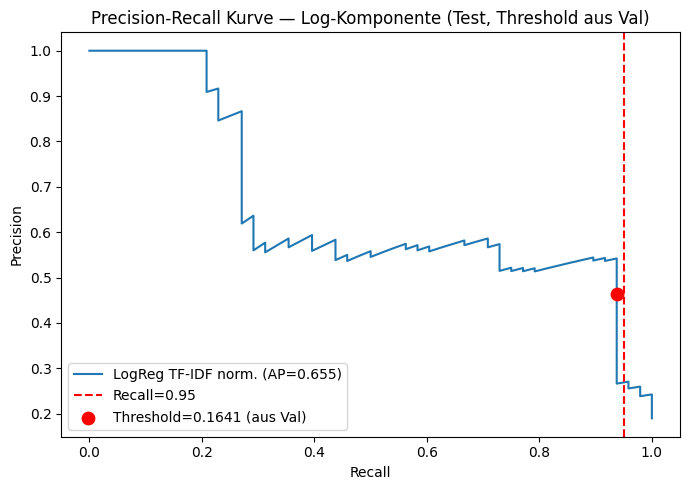

✓ pr_curve_log.png gespeichert


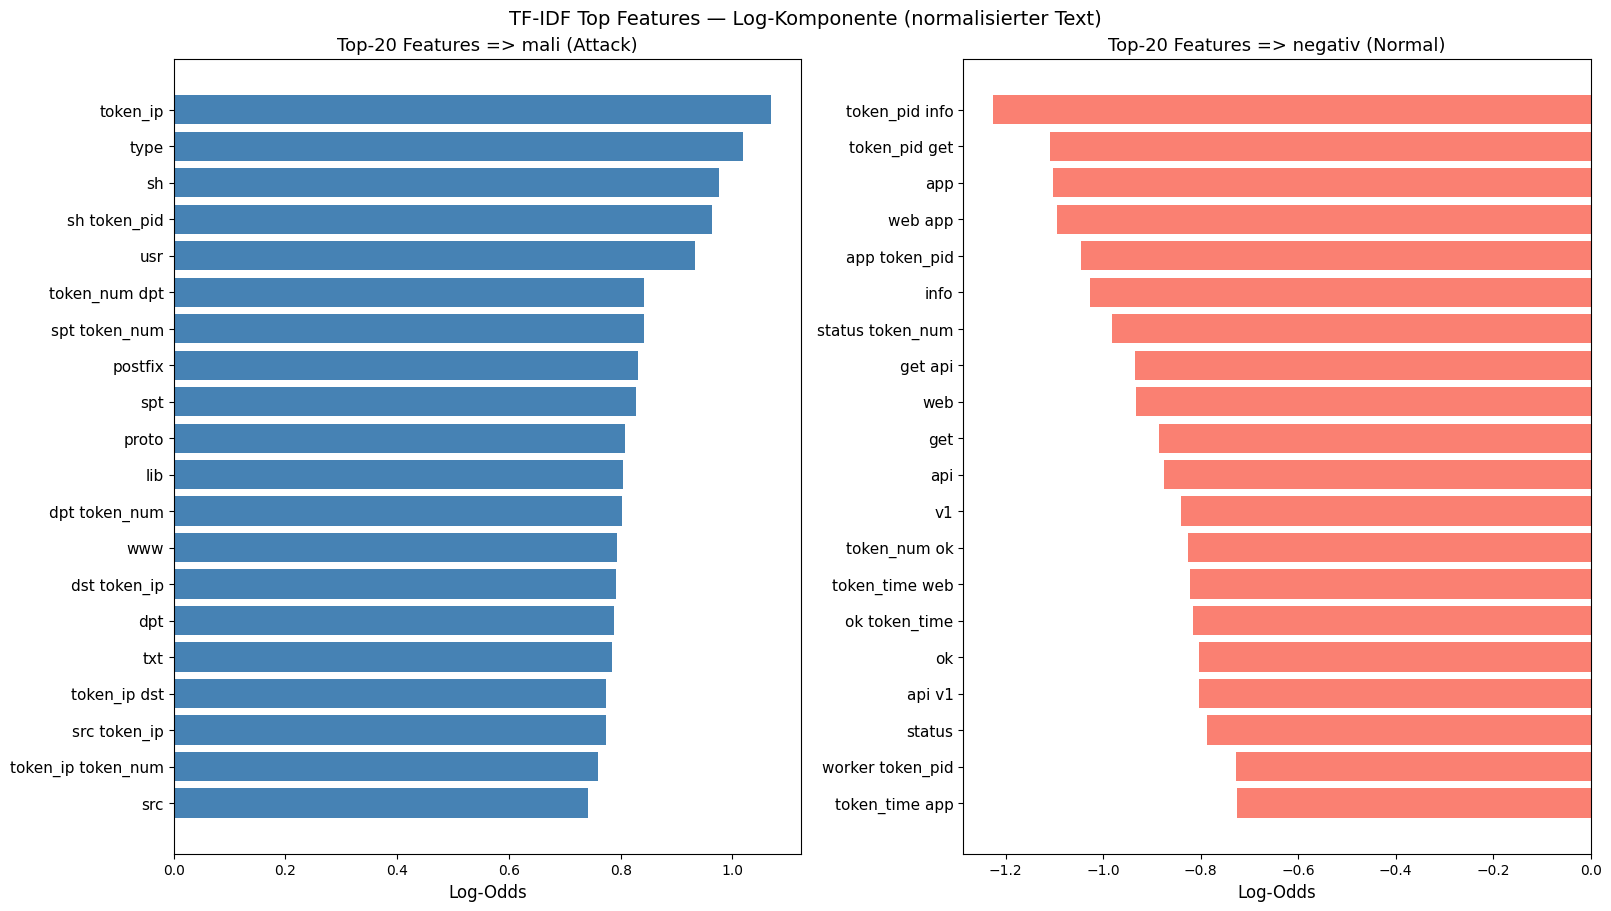

✓ tfidf_top_features.png gespeichert


In [9]:
# ─── Plots ─────────────────────────────────────────────────────────────────────

# PR-Kurve (Testset, Threshold aus Validation)
precisions_test_curve, recalls_test_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls_test_curve, precisions_test_curve,
        label=f'LogReg TF-IDF norm. (AP={ap_test:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter([recall_test], [prec_test], color='red', zorder=5, s=80,
           label=f'Threshold={best_threshold_val:.4f} (aus Val)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — Log-Komponente (Test, Threshold aus Val)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_log.png"), dpi=150)
plt.show()
print("\u2713 pr_curve_log.png gespeichert")

# TF-IDF Top-Features (Log-Odds der Logistic Regression)
feature_names = np.array(vectorizer.get_feature_names_out())
log_odds = log_reg.coef_[0]
top_k = 20

top_pos_idx = np.argsort(log_odds)[-top_k:][::-1]
top_neg_idx = np.argsort(log_odds)[:top_k]

fig, axes = plt.subplots(1, 2, figsize=(16, 9), constrained_layout=True)
axes[0].barh(range(top_k), log_odds[top_pos_idx], color='steelblue')
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels(feature_names[top_pos_idx], fontsize=11)
axes[0].invert_yaxis()
axes[0].set_title('Top-20 Features => mali (Attack)', fontsize=13)
axes[0].set_xlabel('Log-Odds', fontsize=12)
axes[0].tick_params(axis='x', labelsize=10)

axes[1].barh(range(top_k), log_odds[top_neg_idx], color='salmon')
axes[1].set_yticks(range(top_k))
axes[1].set_yticklabels(feature_names[top_neg_idx], fontsize=11)
axes[1].invert_yaxis()
axes[1].set_title('Top-20 Features => negativ (Normal)', fontsize=13)
axes[1].set_xlabel('Log-Odds', fontsize=12)
axes[1].tick_params(axis='x', labelsize=10)

plt.suptitle('TF-IDF Top Features — Log-Komponente (normalisierter Text)', fontsize=14)
plt.savefig(os.path.join(docs_path, "tfidf_top_features.png"), dpi=300, bbox_inches='tight')
plt.show()
print("\u2713 tfidf_top_features.png gespeichert")

## Ergebnis der Log-Komponente

*Aktuelle Werte nach dem Ausführen der Zellen oben ablesen:*

| Metrik | Quelle |
|---|---|
| class_weight | `balanced` (aus Train) |
| Validation-Threshold (Recall ≥ 0.95) | Cell 8 Output |
| Val-Recall_mali @ Threshold | Cell 8 Output |
| Test-AP | Cell 8 Output |
| Test-Recall_mali | Cell 8 Output |
| Test-Precision | Cell 8 Output |
| Test-F1 | Cell 8 Output |
| Test-FPR_total | Cell 8 Output |
| Test-FPR_anom | Cell 8 Output |
| Test-FPR_norm | Cell 8 Output |
| TP / FP / TN / FN | Cell 8 Output |

**Log-Normalisierung Wirkung:**  
Timestamps, PIDs und IPs werden im TF-IDF-Vokabular durch generische Token (`TOKEN_TIME`, `TOKEN_PID`, `TOKEN_IP`) repräsentiert.  
Das Modell kann damit nicht mehr auf spezifische Monatsnamen, Host-IPs oder Prozess-IDs overfiten.

**Artefakte für NB04:**
- `docs/log_test_scores.csv` → Fusion
- `docs/log_val_scores.csv` → Soft-Fusion Threshold